실습7. 일별 집계로 추세 확인
- 일별 평균으로 잡음을 걸러 추세를 원본과 겹쳐 확인

목표
- 일별 평균으로 잡음을 걸러 낸 추세를 원본과 겹쳐 확인

단계
- 하루 단위 평균을 구하고 앞부분 확인
- 원본을 옅게, 일별 평균을 진하게 겹쳐 그리기
- 첫날과 마지막날 평균을 비교해 추세 방향 판정

예상 결과
- 일별 평균 641.07에서 642.35로 상승, 매끄러운 추세선

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/20_engine01_timestamp_sample.csv")

timestamp
2024-03-01    641.067273
2024-03-02    641.340000
2024-03-03    641.557917
Freq: D, Name: temp_out, dtype: float64


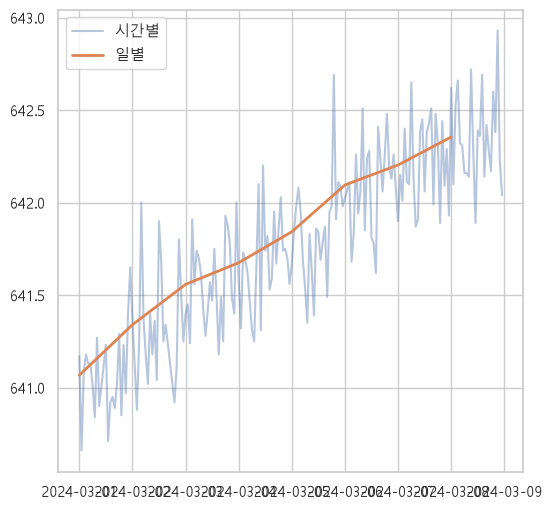

첫날 641.07 / 마지막날 642.35


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.set_index("timestamp").sort_index()

# 하루 단위 평균을 구하고 앞부분 확인
day = df["temp_out"].resample("1D").mean()
print(day.head(3))
# timestamp
# 2024-03-01    641.067273
# 2024-03-02    641.340000
# 2024-03-03    641.557917
# Freq: D, Name: temp_out, dtype: float64

# 원본을 옅게, 일별 평균을 진하게 겹쳐 그리기
plt.figure(figsize=(6, 6))
plt.plot(df.index, df["temp_out"], alpha=0.4, label="시간별")
plt.plot(day.index, day.values, linewidth=2, label="일별")
plt.legend()
plt.show()

# 첫날과 마지막날 평균을 비교해 추세 방향 판정
print(f"첫날 {day.iloc[0].round(2)} / 마지막날 {day.iloc[-1].round(2)}")
# 첫날 641.07 / 마지막날 642.35